In [26]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [13]:
#top skills demanded for data analysts in USA

df_US = df[df['job_country'] == 'United States'].copy()
df_US = df_US.explode('job_skills')
df_US

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,None,None
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,NaN,NaN,Southwest Research Institute,python,"{'cloud': ['aws'], 'libraries': ['tensorflow',..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,NaN,NaN,Southwest Research Institute,c++,"{'cloud': ['aws'], 'libraries': ['tensorflow',..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,NaN,NaN,Southwest Research Institute,java,"{'cloud': ['aws'], 'libraries': ['tensorflow',..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,NaN,NaN,Southwest Research Institute,matlab,"{'cloud': ['aws'], 'libraries': ['tensorflow',..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785692,Data Scientist,Data Scientist- Hybrid Work Location,"Dayton, OH",via Ai-Jobs.net,Full-time,False,"Illinois, United States",2023-04-21 06:02:31,False,True,United States,year,157500.0,NaN,Tenet3,r,"{'programming': ['python', 'matlab', 'r']}"
785703,Data Analyst,Data Analyst - CRYPTOGRAPHY - Full-time,Anywhere,via Snagajob,Full-time,True,"Texas, United States",2023-01-28 06:02:55,True,False,United States,None,NaN,NaN,Axelon Services Corporation,None,None
785705,Data Analyst,Expert Business Data Analyst - Now Hiring,"Oakland, CA",via Snagajob,Full-time,False,"California, United States",2023-01-09 06:00:25,False,False,United States,None,NaN,NaN,PG&E Corporation,sql,"{'analyst_tools': ['tableau'], 'programming': ..."
785705,Data Analyst,Expert Business Data Analyst - Now Hiring,"Oakland, CA",via Snagajob,Full-time,False,"California, United States",2023-01-09 06:00:25,False,False,United States,None,NaN,NaN,PG&E Corporation,python,"{'analyst_tools': ['tableau'], 'programming': ..."


In [14]:
df_US_group = df_US.groupby(['job_title_short', 'job_skills']).size()
df_US_group = df_US_group.reset_index(name='counts').sort_values(by='counts', ascending=False)
df_US_group

,job_title_short,job_skills,counts
886,Data Scientist,python,42379
472,Data Analyst,sql,34452
921,Data Scientist,sql,30034
351,Data Analyst,excel,27519
890,Data Scientist,r,26022
...,...,...,...
1313,Senior Data Engineer,asp.net core,1
228,Cloud Engineer,ms access,1
1020,Machine Learning Engineer,graphql,1
1582,Senior Data Scientist,mariadb,1


In [15]:
#get the top 3 popular job title in the United States
job_titles = df_US['job_title_short'].value_counts().reset_index()
job_titles = job_titles['job_title_short'].head(3).to_list()

df_US_group = df_US_group[df_US_group['job_title_short'].isin(job_titles)]
df_job_total = df_US['job_title_short'].value_counts().reset_index(name = 'jobs_total')




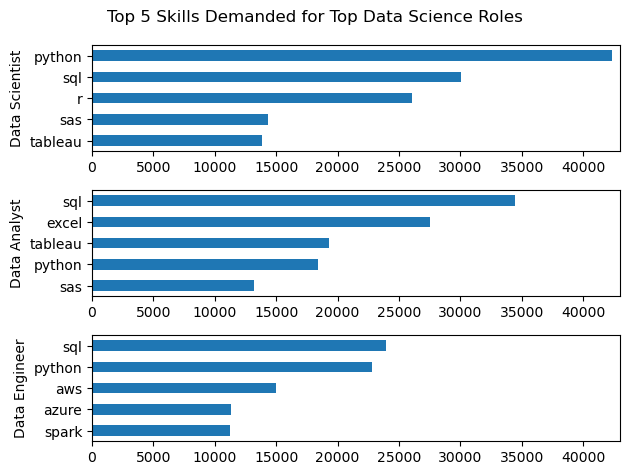

In [16]:
#plotting the latest table.
fig,ax = plt.subplots(3,1)
for i,job_title in enumerate(job_titles):
    df_US_group[df_US_group['job_title_short'] == job_title].head(5).plot(kind='barh', x='job_skills', y='counts', ax=ax[i], legend=False)
    ax[i].set_ylabel(job_title)
    ax[i].invert_yaxis()
    if i==0:
        ax[i].set_xlim(0,43000)
    else:
        pass
    if i>0:
        ax[i].set_xlim(ax[i-1].get_xlim())
    else:
        pass
plt.suptitle('Top 5 Skills Demanded for Top Data Science Roles')
plt.tight_layout()

In [ ]:
#improve the visualization by converting amounts to percentages.
df_job_perc = pd.merge(df_US_group, df_job_total, on='job_title_short', how='left')
df_job_perc['percent'] = 100* df_job_perc['counts'] / df_job_perc['jobs_total']
df_job_perc[df_job_perc['job_title_short'] == 'Data Analyst'].head(5)

,job_title_short,job_skills,counts,jobs_total,percent
1,Data Analyst,sql,34452,254289,13.548364
3,Data Analyst,excel,27519,254289,10.821939
7,Data Analyst,tableau,19311,254289,7.594115
8,Data Analyst,python,18382,254289,7.228783
12,Data Analyst,sas,13200,254289,5.190944


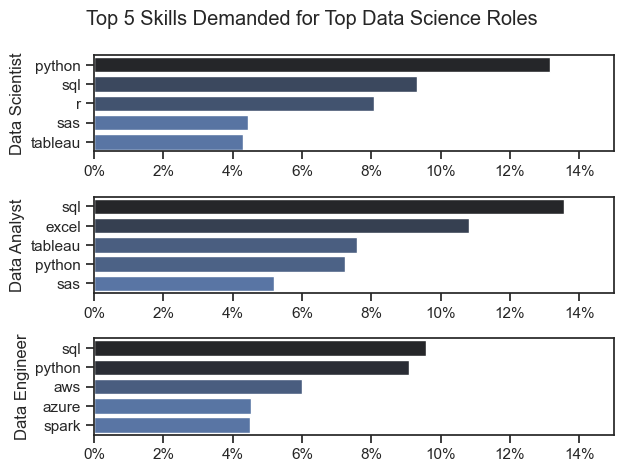

In [ ]:
fig,ax = plt.subplots(3,1)
sns.set_theme(style='ticks')
for i,job_title in enumerate(job_titles):
    df_plot = df_job_perc[df_job_perc['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, y='job_skills', x='percent', ax=ax[i], palette='dark:b_r', hue='percent', legend=False)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    if i==0:
        ax[i].set_xlim(0,15)
    else:
        pass
    if i>0:
        ax[i].set_xlim(ax[i-1].get_xlim())
    else:
        pass
    ax[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'{int(x)}%'))
plt.suptitle('Top 5 Skills Demanded for Top Data Science Roles')
plt.tight_layout()